# Model Training and Validation

In [21]:
import os, glob, warnings, gc, time
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.6g}")
plt.rcParams["figure.figsize"]=(11,4); plt.rcParams["axes.grid"]=True

## 1. Build the data panel aligning all security reference data, signal data, risk factors.

- de-duplicate d3, d4, d9
- drop d11
- calculate forward returns `ret1d_fwd(i,t)=ret1d(i,t+LAG)`, computed with the chunked-shift algorithm from `data_inspection.ipynb`
- a security_id can leave the panel and re-enter months later, so we shift the return only within consecutive trading days (a gap > `GAP_DAYS` trading days opens a new chunk) rather than blindly across the whole
- add one-hot encoding for level I group_id

In [ ]:
#| label: out-build-panel
DATA_DIR="."
PANEL_PATH="panel.parquet"
ALPHA_PATH="alpha.parquet"
LAG=2
GAP_DAYS=5          # a reporting gap > GAP_DAYS trading days breaks a security into a new chunk
TRAIN_END=20161231

REF_FILES = ["security_reference_data_w_ret1d_1.csv","security_reference_data_w_ret1d_2.csv"]
RF_FILES = ["risk_factors_1.csv","risk_factors_2.csv"]
DS_FILES = [f"data_set_{i+1}.csv" for i in range(11)]

REF_DTYPE={"data_date":"int32",
           "security_id":"int32",
           "close_price":"float32",
           "volume":"float32",
           "group_id":"int32",
           "in_trading_universe":"category",
           "ret1d":"float32"}

def add_chunked_fwd_return(ref, lag=LAG, gap_days=GAP_DAYS):
    """ret1d_fwd(i,t) = ret1d(i, t+lag), shifted ONLY within chunks of consecutive trading days. Same as in data_inspection.ipynb"""
    ref = ref.sort_values(["security_id","data_date"])
    all_trading_dates = np.sort(ref["data_date"].unique())
    date_to_idx = pd.Series(np.arange(len(all_trading_dates)), index=all_trading_dates)
    didx = ref["data_date"].map(date_to_idx)
    gap = didx.groupby(ref["security_id"], observed=True).diff()
    new_chunk = (gap > gap_days).fillna(False)                      # True = first row after a gap
    chunk = new_chunk.groupby(ref["security_id"], observed=True).cumsum().astype("int32")
    ref["ret1d_fwd"] = ref.groupby([ref["security_id"], chunk], observed=True)["ret1d"].shift(-lag)
    return ref

def build_panel():
    ref = pd.concat([pd.read_csv(f,dtype=REF_DTYPE) for f in REF_FILES],ignore_index=True)
    ref = ref.drop_duplicates(["data_date","security_id"])
    # calculate forward returns
    ref = add_chunked_fwd_return(ref, lag=LAG, gap_days=GAP_DAYS)

    panel = ref[["data_date","security_id","group_id","in_trading_universe","ret1d","ret1d_fwd"]].copy()
    # merge signals
    for f in DS_FILES:
        col = pd.read_csv(f,nrows=0).columns[-1]
        d = pd.read_csv(f,dtype={"data_date":"int32","security_id":"int32",col:"float32"})
        if col == "d11":
            continue
        elif col in ("d3", "d4"):
            d = d.drop_duplicates(["data_date", "security_id"])
        elif col == "d9":
            d9_spread = d.groupby(["data_date", "security_id"], as_index=False)[col].agg(lambda x: x.max() - x.min())
            d9_spread = d9_spread.rename(columns={col: "d9_spread"})
            d9_mean = d.groupby(["data_date", "security_id"], as_index=False)[col].mean()
            d9_mean = d9_mean.rename(columns={col: "d9_mean"})
            d = d9_mean.merge(d9_spread, on=["data_date", "security_id"])
            col = ["d9_mean", "d9_spread"]
        panel = panel.merge(d,on=["data_date","security_id"],how="left"); del d; gc.collect()
        print(f"Merged {col} into panel")
    # merge risk factors
    rf = pd.concat([pd.read_csv(f) for f in RF_FILES],ignore_index=True).drop_duplicates(["data_date","security_id"])
    for c in [c for c in rf.columns if c.startswith("rf")]: rf[c] = rf[c].astype("float32")
    panel = panel.merge(rf,on=["data_date","security_id"],how="left")
    panel.to_parquet(PANEL_PATH,index=False)
    panel = panel.sort_values(["data_date", "security_id"]).reset_index(drop=True)
    # add one-hot encoding for level I group_id (first 2 digits of group_id)
    group_dummies = pd.get_dummies(panel["group_id"].astype(str).str[:2], prefix="group", dtype="uint8")
    panel = pd.concat([panel, group_dummies], axis=1)
    return panel

panel = build_panel()

SIG=[c for c in panel.columns if c.startswith("d") and c[1].isdigit()]
RF =[c for c in panel.columns if c.startswith("rf") and c[2:].isdigit()]
print(f"Panel dimensions: {panel.shape}")
print(f"Panel columns: {panel.columns.tolist()}")
print(f"Panel time range: {panel['data_date'].min()} to {panel['data_date'].max()}")
print(f"Non-null ret1d_fwd: {panel['ret1d_fwd'].notna().sum():,} / {len(panel):,}")
print(f"Panel head:\n{panel.head()}")

print(SIG)
print(RF)

Merged d1 into panel
Merged d2 into panel
Merged d3 into panel
Merged d4 into panel
Merged d5 into panel
Merged d6 into panel
Merged d7 into panel
Merged d8 into panel
Merged ['d9_mean', 'd9_spread'] into panel
Merged d10 into panel
Panel dimensions: (8800015, 34)
Panel columns: ['data_date', 'security_id', 'group_id', 'in_trading_universe', 'ret1d', 'ret1d_fwd', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9_mean', 'd9_spread', 'd10', 'rf1', 'rf2', 'rf3', 'rf4', 'rf5', 'rf6', 'group_10', 'group_15', 'group_20', 'group_25', 'group_30', 'group_35', 'group_40', 'group_45', 'group_50', 'group_55', 'group_60']
Panel time range: 20100104 to 20171229
Non-null ret1d_fwd: 8,754,849 / 8,800,015
Panel head:
   data_date  security_id  group_id in_trading_universe     ret1d  ret1d_fwd  d1  d2  d3  d4  d5  d6  d7          d8  d9_mean  d9_spread  d10   rf1    rf2  \
0   20100104        77901  20102010                   N 0.0256542 -0.0396703 NaN NaN NaN NaN NaN NaN NaN     134,376   37.485   0.

## 2. Scale returns and signals
Forward Returns:
- Restrict to tradable names in_trading_universe == "Y"
- **Per date** cross-sectionally de-meaned (no look ahead)

Signals & Risk Factors:
- **Per date** Cross-sectional rank -> inverse-normal ("Gaussian rank"), no look ahead

Engineered variables:
- **d9_spread_nz** count nonzero d9_spread, given that d9_spread has ~46% exactly zero, very zero-inflated
- **d1_obs** and **d2_obs**: d1 and d2 are very sparse, only ~1% covered, indicator for whether observed (=1) or NaN (=0)


In [ ]:
#| label: tbl-feature-coverage
#| tbl-cap: "Signal coverage after cleaning and normalization"
from scipy.stats import norm

df = panel[(panel.in_trading_universe == "Y") & panel.ret1d_fwd.notna()].copy()
df = df[df.groupby("data_date")["security_id"].transform("size") >= 50]

# Return target: winsorize then cross-sectionally demean (no look-ahead) ----
def quantile_winsor(s, lo=.01, hi=.99):
    q = s.quantile([lo, hi])
    return s.clip(q.iloc[0], q.iloc[1])
g = df.groupby("data_date", observed=True)
yw = g["ret1d_fwd"].transform(quantile_winsor)
df["y"] = yw - yw.groupby(df["data_date"]).transform("mean")

# Signals and risk factors
# Cross-sectional rank -> inverse-normal ("Gaussian rank"), computed PER DATE (no look-ahead)
# Monotonic, scale/skew/outlier robust + sign-agnostic
# Handles signed heavy-tailed signals (d1, d2: ~30-38% negative) and positive log-normal ones (d8, d10) together
# Fill missing values with 0.0 downstream means "cross-sectional median"
def rank_gauss(s):
    n = s.notna().sum()
    if n < 2:
        return s * 0.0
    r = s.rank(method="average")
    return pd.Series(norm.ppf((r - 0.5) / n), index=s.index)

# d9_spread is ~46% exactly zero (zero-inflated): keep the zero-mass as its OWN feature and
# rank only the strictly-positive magnitude, so the "is there any spread" signal is not smeared.
df["d9_spread_nz"] = (df["d9_spread"] > 0).astype("float32")          # "any spread" indicator
df["d9_spread"]    = df["d9_spread"].where(df["d9_spread"] > 0)        # zeros -> NaN (ranked among positives only)

gg = df.groupby("data_date", observed=True)
for c in SIG + RF:
    df["z_" + c] = gg[c].transform(rank_gauss)

# d1, d2 are only ~1% covered: carry an explicit "is observed" flag so the fillna(0) the models
# use is not silently read as a real (median) signal where the value is simply missing.
for c in ["d1", "d2"]:
    df[f"{c}_obs"] = df[c].notna().astype("float32")

Z_SIG = [f'z_{c}' for c in SIG]
Z_RF  = [f'z_{c}' for c in RF]
EXTRA = ["d9_spread_nz", "d1_obs", "d2_obs"]   # engineered features accompanying the rank-Gaussian signals

print("df Dimension:", df.shape)
print("Unique trading days:", df.data_date.nunique())
print("Median names/day:", int(df.groupby("data_date").size().median()))
print("Transform: cross-sectional rank -> inverse-normal (Gaussian rank) for all of SIG+RF")
print(f"SIG: {SIG}")
print(f"RF: {RF}")
print(f"Gaussian-rank SIG: {Z_SIG}")
print(f"Gaussian-rank RF: {Z_RF}")
print(f"Engineered EXTRA: {EXTRA}")

cov = pd.DataFrame({"coverage": [df[c].notna().mean() for c in SIG],
                    "pct_missing": [df[c].isna().mean()*100 for c in SIG]}, index=SIG)
display(cov.round(3).sort_values("coverage", ascending=False))
display(df.head)

df.sort_values(["data_date", "security_id"], inplace=True)

df Dimension: (3996771, 55)
Unique trading days: 2011
Median names/day: 2043
Transform: cross-sectional rank -> inverse-normal (Gaussian rank) for all of SIG+RF
SIG: ['d1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9_mean', 'd9_spread', 'd10']
RF: ['rf1', 'rf2', 'rf3', 'rf4', 'rf5', 'rf6']
Gaussian-rank SIG: ['z_d1', 'z_d2', 'z_d3', 'z_d4', 'z_d5', 'z_d6', 'z_d7', 'z_d8', 'z_d9_mean', 'z_d9_spread', 'z_d10']
Gaussian-rank RF: ['z_rf1', 'z_rf2', 'z_rf3', 'z_rf4', 'z_rf5', 'z_rf6']
Engineered EXTRA: ['d9_spread_nz', 'd1_obs', 'd2_obs']


,coverage,pct_missing
d8,0.977,2.253
d9_mean,0.923,7.721
d9_spread,0.761,23.899
d10,0.563,43.742
d1,0.015,98.544
d4,0.015,98.535
d2,0.014,98.619
d5,0.014,98.604
d3,0.013,98.694
d6,0.013,98.686


<bound method NDFrame.head of          data_date  security_id  group_id in_trading_universe       ret1d   ret1d_fwd  d1  d2  d3  d4  d5  d6  d7          d8  d9_mean  d9_spread  d10    rf1  \
1         20100104        78001  20101010                   Y   0.0343777    0.050351 NaN NaN NaN NaN NaN NaN NaN     471,189   18.985  0.0300007  244  0.538   
2         20100104        78401  20104020                   Y   0.0282724    0.011634 NaN NaN NaN NaN NaN NaN NaN 1.06476e+06      NaN        NaN  NaN  0.776   
7         20100104        85301  45201020                   Y   0.0595814 -0.00750721 NaN NaN NaN NaN NaN NaN NaN 2.30984e+06    34.66  0.0999985  NaN  1.151   
12        20100104        97801  40301020                   Y   0.0285407  0.00878441 NaN NaN NaN NaN NaN NaN NaN 3.48338e+06      1.4       0.08   15  2.081   
13        20100104       100701  55102010                   Y   0.0145324  -0.0157153 NaN NaN NaN NaN NaN NaN NaN     131,927    2.365       0.41  NaN -0.937   
... 

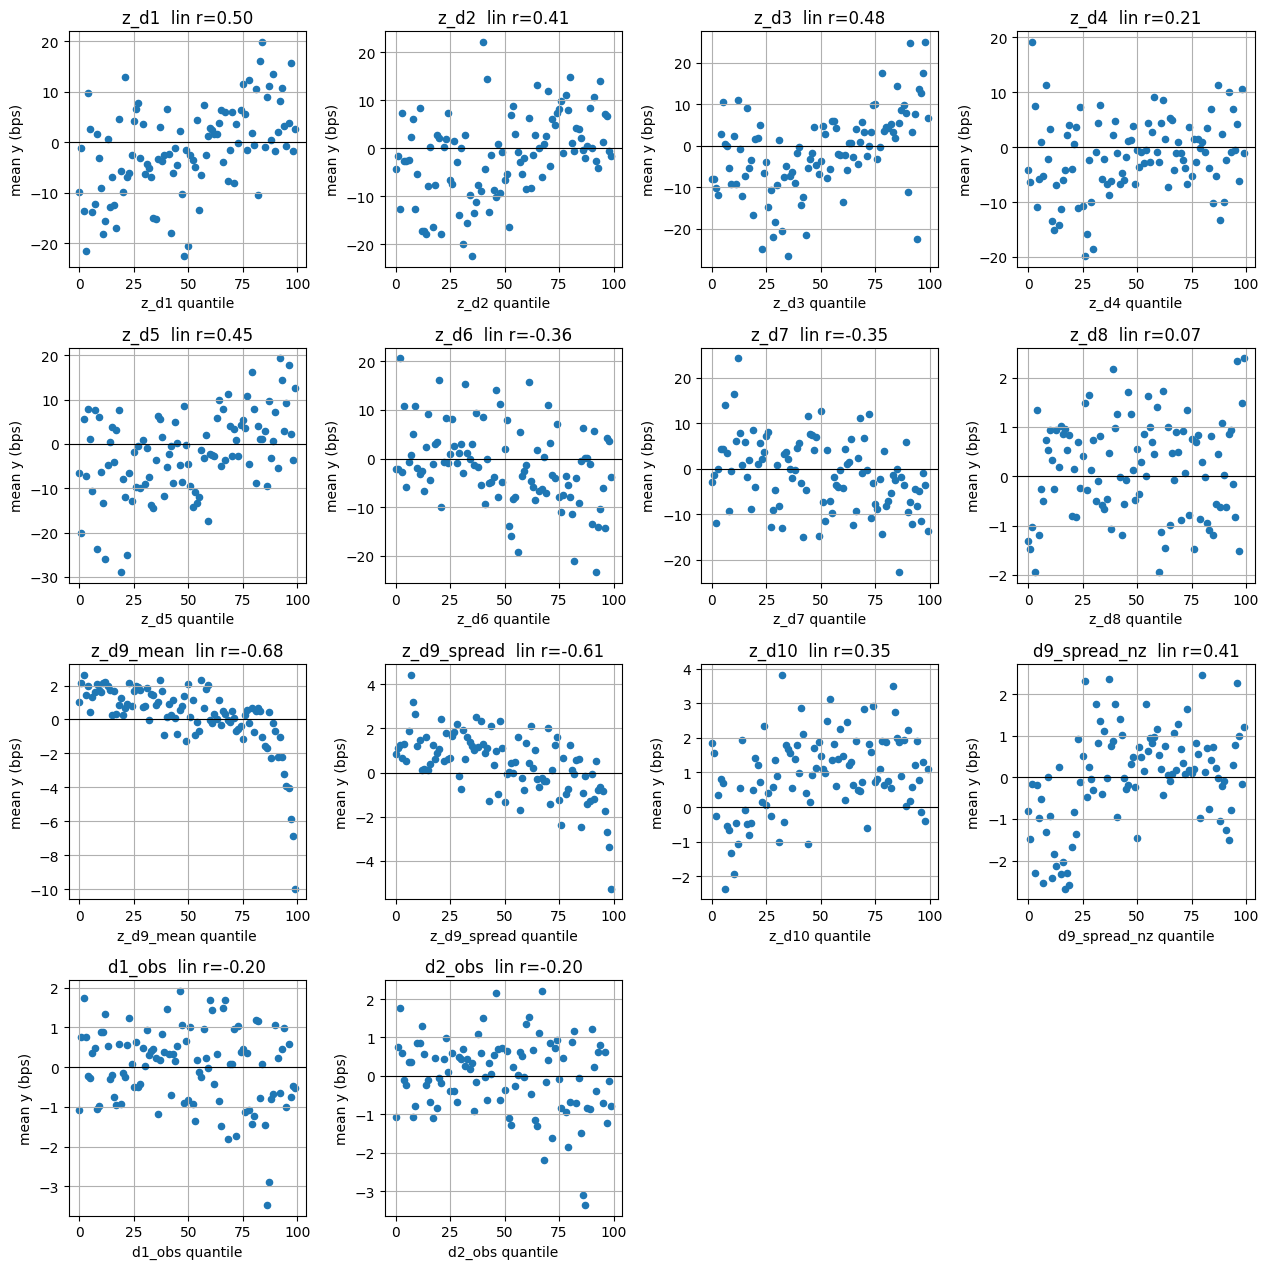

In [ ]:
#| label: fig-quantile-profile
#| fig-cap: "Mean forward return by signal quantile"
# Plot quantile profile for each signal
def quantile_profile(frame, col, q=100):
    d = frame[["data_date", col, "y"]].dropna()
    d["b"] = d.groupby("data_date")[col].transform(lambda s: pd.qcut(s.rank(method="first"), q, labels=False, duplicates="drop"))
    prof = d.groupby("b")["y"].mean()
    xx = prof.index.values.astype(float)
    return prof, np.corrcoef(xx, prof.values)[0,1]

nrows = 4
ncols = 4
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 3.2*nrows), sharey=False)
axes = axes.flatten()

for i, c in enumerate(Z_SIG + EXTRA):
    if i >= len(axes):
        break
    a = axes[i]
    prof, lin = quantile_profile(df, c)
    a.scatter(prof.index, prof.values * 1e4, s=20)
    a.axhline(0, color="k", lw=.8)
    a.set_title(f"{c}  lin r={lin:.2f}")
    a.set_xlabel(f"{c} quantile")
    a.set_ylabel("mean y (bps)")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Define helpers

In [25]:
#| label: out-data-split
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


DATE = "data_date"
ID = "security_id"
Y = "y"

# feature set: rank-Gaussian signals + engineered extras (zero-spread flag, d1/d2 observed flags)
# + level-I group one-hots.
# NOTE: level-I group_id one-hots were tested and DROPPED — as features they add static
# industry tilts + ill-conditioning and REDUCE out-of-sample Sharpe (they do not predict the
# cross-sectionally demeaned forward return). Industry/factor exposure is handled by
# risk-factor neutralisation in portfolio_construction.ipynb instead.
ALPHA = [
    "z_d1", "z_d2", "z_d3", "z_d4", "z_d5",
    "z_d6", "z_d7", "z_d8", "z_d9_mean", "z_d9_spread", "z_d10",
    "d9_spread_nz", "d1_obs", "d2_obs",
]

RISK = ["z_rf1", "z_rf2", "z_rf3", "z_rf4", "z_rf5", "z_rf6"]


# ============================================================
# OBJECTIVE = INFORMATION COEFFICIENT (IC), not MSE/R^2.
# IC = mean over dates of the cross-sectional Spearman rank correlation between the forecast
# and the realized (demeaned) forward return. This is what the book monetises (rank-ordering
# names per day), so every model/hyperparameter choice below is made to MAXIMISE IC. MSE/R^2
# are still reported for reference but are NOT used for selection.
# ============================================================
def daily_rank_ic(dates, y_true, y_pred):
    """Mean daily cross-sectional Spearman rank IC (vectorised: Pearson on per-date ranks)."""
    s = pd.DataFrame({"d": np.asarray(dates),
                      "y": np.asarray(y_true, float),
                      "p": np.asarray(y_pred, float)}).dropna()
    if s.empty:
        return np.nan
    s["ry"] = s.groupby("d")["y"].rank()
    s["rp"] = s.groupby("d")["p"].rank()
    ybar = s.groupby("d")["ry"].transform("mean")
    pbar = s.groupby("d")["rp"].transform("mean")
    dy, dp = s["ry"] - ybar, s["rp"] - pbar
    num = (dy * dp).groupby(s["d"]).sum()
    den = np.sqrt((dy * dy).groupby(s["d"]).sum() * (dp * dp).groupby(s["d"]).sum())
    return float((num / den.replace(0, np.nan)).mean())


def prep_df(df):
    d = df.copy()

    d["ym"] = d[DATE] // 100

    d[Y] = pd.to_numeric(d[Y], errors="coerce")
    d = d.dropna(subset=[Y]).copy()

    for c in ALPHA + RISK:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    return d


def month_split(d, train_frac=0.7, cutoff=None):
    months = np.sort(d["ym"].unique())

    if cutoff is not None:
        train_months = months[months <= cutoff]
        test_months = months[months > cutoff]
    else:
        cut = int(len(months) * train_frac)
        train_months = months[:cut]
        test_months = months[cut:]

    train = d[d["ym"].isin(train_months)].copy()
    test = d[d["ym"].isin(test_months)].copy()

    return train, test, train_months, test_months


def rolling_splits(months, lookback=24, n_splits=4):
    months = np.array(sorted(months))
    tscv = TimeSeriesSplit(n_splits=n_splits, max_train_size=lookback)

    return [
        (months[tr_idx], months[val_idx])
        for tr_idx, val_idx in tscv.split(months)
    ]


def neutralize_by_date(df, y_col, x_cols, out_col, fill_x=0.0):
    """
    For each date:
        y_col = intercept + x_cols + residual
        out_col = residual

    Used for:
        1. residualizing target returns
        2. neutralizing model predictions
    """
    d = df.copy()
    d[out_col] = np.nan

    for _, idx in d.groupby(DATE).groups.items():
        g = d.loc[idx]

        y = pd.to_numeric(g[y_col], errors="coerce").values.astype(float)
        X = g[x_cols].fillna(fill_x).values.astype(float)

        valid = np.isfinite(y)

        if valid.sum() <= len(x_cols) + 5:
            continue

        Xv = X[valid]
        yv = y[valid]

        Xv = np.column_stack([np.ones(len(Xv)), Xv])

        try:
            beta = np.linalg.lstsq(Xv, yv, rcond=None)[0]
            resid = yv - Xv @ beta
            d.loc[g.index[valid], out_col] = resid
        except np.linalg.LinAlgError:
            continue

    return d


def cv_score(data, features, target, model_fn, splits, fill_nan):
    rows = []

    for k, (trm, valm) in enumerate(splits):
        A = data[data["ym"].isin(trm)]
        B = data[data["ym"].isin(valm)]

        Xtr = A[features]
        Xva = B[features]

        if fill_nan:
            Xtr = Xtr.fillna(0.0)
            Xva = Xva.fillna(0.0)

        model = model_fn()
        model.fit(Xtr, A[target])

        pred = model.predict(Xva)

        rows.append({
            "fold": k,
            "ic": daily_rank_ic(B[DATE].values, B[target].values, pred),   # <- selection objective
            "mse": mean_squared_error(B[target], pred),
            "r2": r2_score(B[target], pred),
            "train": f"{trm.min()}-{trm.max()}",
            "val": f"{valm.min()}-{valm.max()}",
        })

    return pd.DataFrame(rows)


def fit_holdout(train, test, features, target, model_fn, fill_nan):
    Xtr = train[features]
    Xte = test[features]

    if fill_nan:
        Xtr = Xtr.fillna(0.0)
        Xte = Xte.fillna(0.0)

    model = model_fn()
    model.fit(Xtr, train[target])

    pred = model.predict(Xte)

    keep_cols = [DATE, ID, "ym", Y, target] + RISK
    keep_cols = list(dict.fromkeys([c for c in keep_cols if c in test.columns]))

    pred_df = test[keep_cols].copy()
    pred_df["pred_raw"] = pred

    pred_df = neutralize_by_date(
        pred_df,
        y_col="pred_raw",
        x_cols=RISK,
        out_col="pred_neut"
    )

    return model, pred_df, {
        "test_ic":  daily_rank_ic(test[DATE].values, test[target].values, pred),   # <- primary read
        "test_mse": mean_squared_error(test[target], pred),
        "test_r2":  r2_score(test[target], pred),
    }


data = prep_df(df)

# y_raw is the winsorized forward return
data["y_raw"] = data[Y]

# y_idio is residualized winsorized forward return
data = neutralize_by_date(
    data,
    y_col="y_raw",
    x_cols=RISK,
    out_col="y_idio"
)

data = data.dropna(subset=["y_raw", "y_idio"]).copy()

train, test, train_months, test_months = month_split(data, cutoff=201612)
splits = rolling_splits(train_months, lookback=24, n_splits=4)

print("ALPHA:", ALPHA)
print("RISK:", RISK)
print("Selection objective: daily rank IC (Spearman), MSE/R^2 reported for reference only")
print("train:", train.shape, train_months.min(), train_months.max())
print("test:", test.shape, test_months.min(), test_months.max())

ALPHA: ['z_d1', 'z_d2', 'z_d3', 'z_d4', 'z_d5', 'z_d6', 'z_d7', 'z_d8', 'z_d9_mean', 'z_d9_spread', 'z_d10', 'd9_spread_nz', 'd1_obs', 'd2_obs']
RISK: ['z_rf1', 'z_rf2', 'z_rf3', 'z_rf4', 'z_rf5', 'z_rf6']
Selection objective: daily rank IC (Spearman), MSE/R^2 reported for reference only
train: (3444193, 58) 201001 201612
test: (552578, 58) 201701 201712


## 6. Forward-stepwise Linear Regression

Forward-stepwise OLS, no regularization.
- M0 : null model, intercept only (just the target mean).
- M1 : fit each candidate ALONE, keep the single best one
- Mk : add the ONE remaining signal that most improves the criterion.
- Criterion is the **in-sample information coefficient (IC)** — the mean daily cross-sectional correlation between the fitted forecast and the target. A signal enters only if it raises train IC AND its newly added coefficient clears the t-test threshold (p-value <= P_ENTER).
- Stop when no remaining signal raises IC (or none clears P_ENTER).

Selection is in-sample on train, then the chosen model is scored on the 2017 holdout by **test IC**.

In [26]:
#| label: out-stepwise
from scipy import stats
from sklearn.linear_model import LinearRegression

ols_fn = lambda: LinearRegression()

def forward_stepwise_ols(frame, candidates, target, p_enter=0.05):
    y = frame[target].to_numpy(float)
    X = frame[candidates].fillna(0.0).to_numpy(float)
    n = len(y)

    # --- precompute per-date structure for a fast daily (Pearson) IC of any prediction vector ---
    # On rank-Gaussian features with a demeaned target this Pearson-on-fitted-values IC tracks the
    # Spearman rank IC closely, but is cheap enough to evaluate inside the greedy O(p^2) search.
    codes = pd.factorize(frame[DATE].to_numpy())[0]
    K = int(codes.max()) + 1
    cnt = np.bincount(codes, minlength=K).astype(float)
    cnt_safe = np.maximum(cnt, 1.0)
    ybar = np.bincount(codes, weights=y, minlength=K) / cnt_safe
    ydm = y - ybar[codes]                                   # daily-demeaned target (fixed)
    syy = np.bincount(codes, weights=ydm * ydm, minlength=K)

    def daily_ic(yhat):
        pbar = np.bincount(codes, weights=yhat, minlength=K) / cnt_safe
        pdm = yhat - pbar[codes]
        num = np.bincount(codes, weights=ydm * pdm, minlength=K)
        spp = np.bincount(codes, weights=pdm * pdm, minlength=K)
        den = np.sqrt(syy * spp)
        ok = den > 0
        return float(np.mean(num[ok] / den[ok])) if ok.any() else 0.0

    def fit_and_score(cols_idx):
        Xsub = np.column_stack([np.ones(n), X[:, cols_idx]])
        beta, _, _, _ = np.linalg.lstsq(Xsub, y, rcond=None)
        yhat = Xsub @ beta

        ic = daily_ic(yhat)                                 # <- objective: in-sample daily IC

        # p-value for the last added coefficient (entry gate only, not the objective)
        ss_res = np.sum((y - yhat) ** 2)
        sigma2 = ss_res / (n - Xsub.shape[1])
        try:
            cov = np.linalg.inv(Xsub.T @ Xsub) * sigma2
            se = np.sqrt(cov[-1, -1])
            t_stat = beta[-1] / se
            p_val = float(2 * stats.t.sf(abs(t_stat), df=n - Xsub.shape[1]))
        except np.linalg.LinAlgError:
            p_val = 1.0

        return ic, p_val

    selected_idx, selected, path = [], [], []
    cur_ic = 0.0
    remaining = list(range(len(candidates)))

    # null model
    path.append(dict(
        step=0,
        added="(null: mean only)",
        n_terms=0,
        ic=0.0,
        p_value=np.nan
    ))

    while remaining:
        best_ic, best_j, best_pval = -np.inf, None, 1.0

        for j in remaining:
            ic, pval = fit_and_score(selected_idx + [j])

            if ic > best_ic:
                best_ic, best_j, best_pval = ic, j, pval

        if best_j is None or best_pval > p_enter or best_ic <= cur_ic:
            break

        selected_idx.append(best_j)
        selected.append(candidates[best_j])
        remaining.remove(best_j)
        cur_ic = best_ic

        path.append(dict(
            step=len(selected),
            added=candidates[best_j],
            n_terms=len(selected),
            ic=best_ic,
            p_value=best_pval
        ))

    return selected, pd.DataFrame(path)


add_results = []

for target in ["y_raw", "y_idio"]:
    selected, path = forward_stepwise_ols(train, ALPHA, target)

    if selected:
        model, pred, test_stats = fit_holdout(
            train, test, selected, target, ols_fn, fill_nan=True
        )
    else:
        yhat = np.full(len(test), train[target].mean())
        test_stats = {
            "test_ic":  daily_rank_ic(test[DATE].values, test[target].values, yhat),
            "test_mse": mean_squared_error(test[target], yhat),
            "test_r2":  r2_score(test[target], yhat),
        }
        model = None
        pred = None

    add_results.append({
        "family": "additive_ols",
        "target": target,
        "selected": selected,
        "path": path,
        "model": model,
        "pred": pred,
        **test_stats
    })

    print(f"\nADDITIVE OLS target: {target}  (objective=train IC, p_enter=0.05)")
    print(path.to_string(index=False))
    print("Final variables selected:", selected)
    print(f"Test IC={test_stats['test_ic']:.6g}   Test MSE={test_stats['test_mse']:.6g}   Test R^2={test_stats['test_r2']:.6g}")


ADDITIVE OLS target: y_raw  (objective=train IC, p_enter=0.05)
 step             added  n_terms         ic     p_value
    0 (null: mean only)        0          0         NaN
    1         z_d9_mean        1 0.00792371 2.35976e-54
    2      d9_spread_nz        2 0.00975796 3.58824e-31
    3              z_d1        3   0.010235 1.70795e-08
    4       z_d9_spread        4  0.0104924 0.000242044
    5              z_d5        5  0.0107295 4.33593e-06
    6            d2_obs        6  0.0108921  0.00176004
    7              z_d7        7      0.011  0.00043692
Final variables selected: ['z_d9_mean', 'd9_spread_nz', 'z_d1', 'z_d9_spread', 'z_d5', 'd2_obs', 'z_d7']
Test IC=0.00472222   Test MSE=0.000254303   Test R^2=-8.53421e-05

ADDITIVE OLS target: y_idio  (objective=train IC, p_enter=0.05)
 step             added  n_terms         ic     p_value
    0 (null: mean only)        0          0         NaN
    1         z_d9_mean        1 0.00524125  3.5979e-22
    2      d9_spread_nz     

## 4. PCA regression

Cross-validation chooses the number of components by MSE, we then refit on train and score the 2017 holdout.


PCA target: y_raw  — 5 components explain 96.6% variance
Best n_components: 5   cumulative explained var = 0.966
Test: {'test_ic': 0.003948280001035105, 'test_mse': 0.00025430324874897573, 'test_r2': -8.688524870681391e-05}


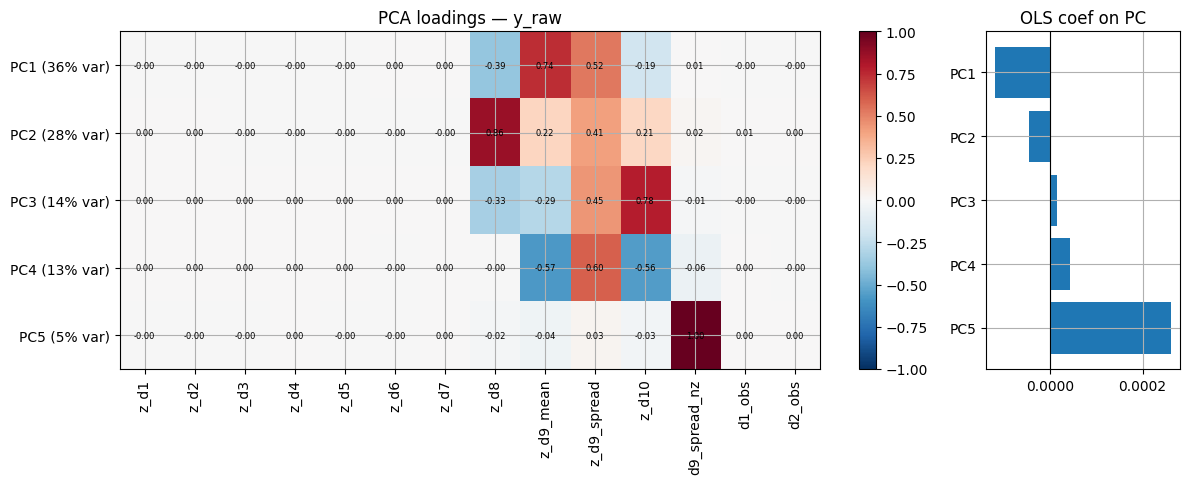

,z_d1,z_d2,z_d3,z_d4,z_d5,z_d6,z_d7,z_d8,z_d9_mean,z_d9_spread,z_d10,d9_spread_nz,d1_obs,d2_obs
PC1,-0.003,-0.004,-0.002,-0.001,-0.002,0,0,-0.386,0.735,0.524,-0.189,0.007,-0.002,-0.002
PC2,0.001,0.001,-0,-0,-0.001,-0,-0.001,0.862,0.216,0.408,0.21,0.022,0.005,0.005
PC3,0.003,0.004,0.002,0.002,0.002,0,0,-0.328,-0.289,0.445,0.781,-0.011,-0.004,-0.004
PC4,0,0,0,0,0.001,-0,0.001,-0.004,-0.572,0.6,-0.556,-0.055,0,-0
PC5,-0.002,-0.002,-0,0.001,-0,-0,0.001,-0.02,-0.045,0.026,-0.025,0.998,0.001,0.002



PCA target: y_idio  — 5 components explain 96.6% variance
Best n_components: 5   cumulative explained var = 0.966
Test: {'test_ic': 0.0033221419866727416, 'test_mse': 0.00023093412210146367, 'test_r2': -5.187037276588313e-05}


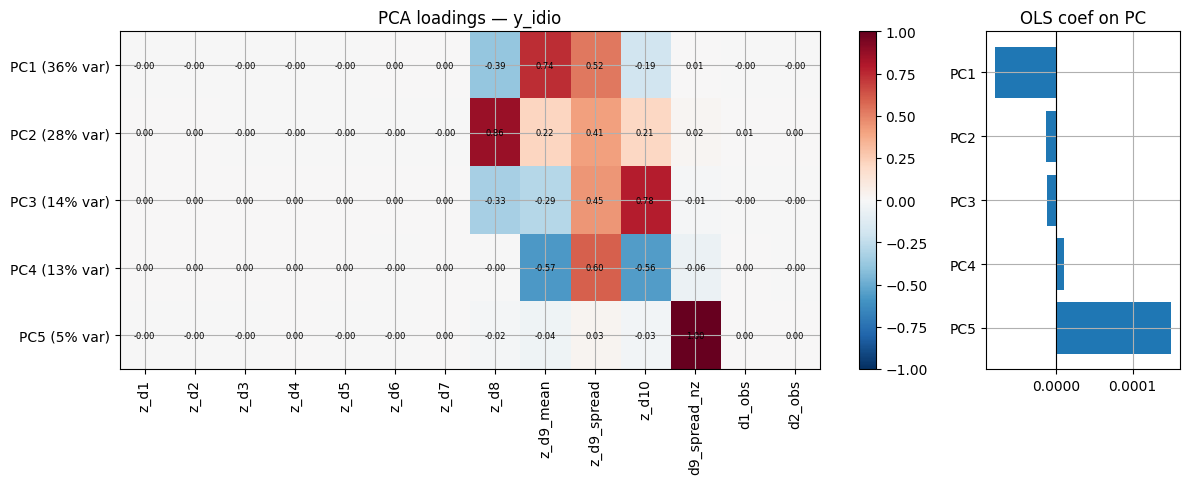

,z_d1,z_d2,z_d3,z_d4,z_d5,z_d6,z_d7,z_d8,z_d9_mean,z_d9_spread,z_d10,d9_spread_nz,d1_obs,d2_obs
PC1,-0.003,-0.004,-0.002,-0.001,-0.002,0,0,-0.386,0.735,0.524,-0.189,0.007,-0.002,-0.002
PC2,0.001,0.001,-0,-0,-0.001,-0,-0.001,0.862,0.216,0.408,0.21,0.022,0.005,0.005
PC3,0.003,0.004,0.002,0.002,0.002,0,0,-0.328,-0.289,0.445,0.781,-0.011,-0.004,-0.004
PC4,0,0,0,0,0.001,-0,0.001,-0.004,-0.572,0.6,-0.556,-0.055,0,-0
PC5,-0.002,-0.002,-0,0.001,-0,-0,0.001,-0.02,-0.045,0.026,-0.025,0.998,0.001,0.002


In [27]:
#| label: fig-pca
#| fig-cap: "PCA of the signal set"
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

VARIANCE_THRESHOLD = 0.95

def pca_ols_fn(n_components):
    return lambda: Pipeline([
        ("pca", PCA(n_components=n_components, svd_solver="full")),
        ("ols", LinearRegression()),
    ])

pca_results = []
for target in ["y_raw", "y_idio"]:
    # fit PCA on train to find number of components explaining 95% variance
    _pca = PCA(svd_solver="full")
    _pca.fit(train[ALPHA].fillna(0.0))
    cumvar = np.cumsum(_pca.explained_variance_ratio_)
    best_k = int(np.searchsorted(cumvar, VARIANCE_THRESHOLD) + 1)

    print(f"\nPCA target: {target}  — {best_k} components explain {cumvar[best_k-1]*100:.1f}% variance")

    # refit on train (PCA fit on train only), score holdout
    model, pred, test_stats = fit_holdout(train, test, ALPHA, target, pca_ols_fn(best_k), fill_nan=True)
    pca, ols = model.named_steps["pca"], model.named_steps["ols"]
    evr = pca.explained_variance_ratio_
    loadings = pd.DataFrame(pca.components_,
                            index=[f"PC{i+1}" for i in range(best_k)], columns=ALPHA)

    pca_results.append({"family": "pca_ols", "target": target, "best_k": best_k,
                        "cv": None, "model": model, "pred": pred,
                        "loadings": loadings, "evr": evr, **test_stats})

    print(f"Best n_components: {best_k}   cumulative explained var = {evr.sum():.3f}")
    print("Test:", test_stats)

    # display component loadings (PC x signal) + each PC's OLS weight
    fig, ax = plt.subplots(1, 2, figsize=(12, 0.55 * best_k + 2.2),
                           gridspec_kw={"width_ratios": [4, 1]})
    im = ax[0].imshow(loadings.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    ax[0].set_xticks(range(len(ALPHA))); ax[0].set_xticklabels(ALPHA, rotation=90)
    ax[0].set_yticks(range(best_k))
    ax[0].set_yticklabels([f"PC{i+1} ({evr[i]*100:.0f}% var)" for i in range(best_k)])
    for (i, j), z in np.ndenumerate(loadings.values):
        ax[0].text(j, i, f"{z:.2f}", ha="center", va="center", fontsize=6)
    ax[0].set_title(f"PCA loadings — {target}")
    fig.colorbar(im, ax=ax[0], fraction=0.046)
    ax[1].barh(range(best_k), ols.coef_)
    ax[1].set_yticks(range(best_k)); ax[1].set_yticklabels([f"PC{i+1}" for i in range(best_k)])
    ax[1].invert_yaxis(); ax[1].axvline(0, color="k", lw=.8)
    ax[1].set_title("OLS coef on PC")
    plt.tight_layout(); plt.show()
    display(loadings.round(3))


## 5. Regularized Regression models (Ridge, Lasso, Elastic-Net)

In [ ]:
#| label: out-reg
reg_models = {
    "ridge_1": lambda: Ridge(alpha=1.0),
    "ridge_10": lambda: Ridge(alpha=10.0),
    "ridge_100": lambda: Ridge(alpha=100.0),
    "ridge_1000": lambda: Ridge(alpha=1000.0),

    "lasso_1e-4": lambda: Lasso(alpha=1e-4, max_iter=3000),
    "lasso_1e-3": lambda: Lasso(alpha=1e-3, max_iter=3000),

    "enet_1e-4_l1_0.5": lambda: ElasticNet(alpha=1e-4, l1_ratio=0.5, max_iter=3000),
    "enet_1e-3_l1_0.5": lambda: ElasticNet(alpha=1e-3, l1_ratio=0.5, max_iter=3000),
}


def compare_fixed_models(data, features, target, models, splits, fill_nan):
    rows = []

    for name, model_fn in models.items():
        folds = cv_score(
            data=data,
            features=features,
            target=target,
            model_fn=model_fn,
            splits=splits,
            fill_nan=fill_nan
        )

        rows.append({
            "model": name,
            "cv_ic": folds["ic"].mean(),     # objective to maximize
            "cv_mse": folds["mse"].mean(),
            "cv_r2": folds["r2"].mean(),
        })

    # rank by IC (descending)
    return pd.DataFrame(rows).sort_values("cv_ic", ascending=False).reset_index(drop=True)


reg_results = []
for target in ["y_raw", "y_idio"]:
    cv = compare_fixed_models(
        data=train,
        features=ALPHA,
        target=target,
        models=reg_models,
        splits=splits,
        fill_nan=True
    )

    best_name = cv.iloc[0]["model"]          # highest CV IC
    best_fn = reg_models[best_name]

    model, pred, test_stats = fit_holdout(
        train=train,
        test=test,
        features=ALPHA,
        target=target,
        model_fn=best_fn,
        fill_nan=True
    )

    reg_results.append({
        "family": "regression",
        "target": target,
        "best_model": best_name,
        "cv": cv,
        "model": model,
        "pred": pred,
        **test_stats,
    })

    print("\nREG target:", target, "(selected by CV IC)")
    print(cv)
    print("Best:", best_name, test_stats)


REG target: y_raw (selected by CV IC)
              model      cv_ic      cv_mse       cv_r2
0        ridge_1000  0.0119558 0.000287758 6.75105e-05
1           ridge_1  0.0119506 0.000287758 6.57722e-05
2          ridge_10  0.0119503 0.000287758 6.57948e-05
3         ridge_100  0.0119497 0.000287758 6.59875e-05
4  enet_1e-4_l1_0.5  0.0111314  0.00028776 5.44872e-05
5        lasso_1e-4 0.00959007 0.000287768 2.61777e-05
6        lasso_1e-3        NaN 0.000287776           0
7  enet_1e-3_l1_0.5        NaN 0.000287776           0
Best: ridge_1000 {'test_ic': 0.004562619087325964, 'test_mse': 0.0002543026498995927, 'test_r2': -8.453018082166253e-05}

REG target: y_idio (selected by CV IC)
              model      cv_ic      cv_mse       cv_r2
0        ridge_1000 0.00793319 0.000251937 2.19627e-05
1         ridge_100 0.00792013 0.000251937 2.05893e-05
2          ridge_10 0.00791635 0.000251938  2.0346e-05
3           ridge_1 0.00791539 0.000251938 2.03165e-05
4  enet_1e-4_l1_0.5 0.00666873

## 6. Tree-based Models: XGBoost, LightGBM

In [ ]:
#| label: out-trees
def xgb_factory(params):
    return lambda: XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
        verbosity=0,
        **params
    )


def lgbm_factory(params):
    return lambda: LGBMRegressor(
        objective="regression",
        n_jobs=-1,
        random_state=42,
        verbose=-1,
        **params
    )


xgb_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.05],
    "max_depth": [2, 3],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [50, 100],
    "reg_lambda": [5.0, 10.0],
}

lgbm_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.05],
    "num_leaves": [7, 15],
    "min_child_samples": [200, 500],
    "subsample": [0.8],
    "subsample_freq": [1],
    "colsample_bytree": [0.8],
    "reg_lambda": [5.0, 10.0],
}


def grid_search_trees(data, features, target, splits):
    rows = []
    model_fns = {}

    for params in ParameterGrid(xgb_grid):
        name = "xgb_" + "_".join(f"{k}={v}" for k, v in params.items())
        model_fn = xgb_factory(params)

        folds = cv_score(
            data=data,
            features=features,
            target=target,
            model_fn=model_fn,
            splits=splits,
            fill_nan=False
        )

        rows.append({
            "model": name,
            "family": "xgboost",
            "cv_ic": folds["ic"].mean(),     # maximize objective
            "cv_mse": folds["mse"].mean(),
            "cv_r2": folds["r2"].mean(),
            "params": params,
        })

        model_fns[name] = model_fn

    for params in ParameterGrid(lgbm_grid):
        name = "lgbm_" + "_".join(f"{k}={v}" for k, v in params.items())
        model_fn = lgbm_factory(params)

        folds = cv_score(
            data=data,
            features=features,
            target=target,
            model_fn=model_fn,
            splits=splits,
            fill_nan=False
        )

        rows.append({
            "model": name,
            "family": "lightgbm",
            "cv_ic": folds["ic"].mean(),     # maximize objective
            "cv_mse": folds["mse"].mean(),
            "cv_r2": folds["r2"].mean(),
            "params": params,
        })

        model_fns[name] = model_fn

    # rank by IC (descending): best forecast quality first
    out = pd.DataFrame(rows).sort_values("cv_ic", ascending=False).reset_index(drop=True)

    return out, model_fns


tree_results = []

for target in ["y_raw", "y_idio"]:
    cv, model_fns = grid_search_trees(
        data=train,
        features=ALPHA,
        target=target,
        splits=splits
    )

    best_name = cv.iloc[0]["model"]          # highest CV IC
    best_fn = model_fns[best_name]

    model, pred, test_stats = fit_holdout(
        train=train,
        test=test,
        features=ALPHA,
        target=target,
        model_fn=best_fn,
        fill_nan=False
    )

    tree_results.append({
        "family": cv.iloc[0]["family"],
        "target": target,
        "best_model": best_name,
        "best_params": cv.iloc[0]["params"],
        "cv": cv,
        "model": model,
        "pred": pred,
        **test_stats,
    })

    print("\nTREE target:", target, "(selected by CV IC)")
    print(cv.head(10))
    print("Best:", best_name)
    print("Best params:", cv.iloc[0]["params"])
    print("Test:", test_stats)


TREE target: y_raw (selected by CV IC)
                                               model    family     cv_ic      cv_mse       cv_r2                                             params
0  xgb_colsample_bytree=0.8_learning_rate=0.01_ma...   xgboost 0.0134192 0.000287751 8.85758e-05  {'colsample_bytree': 0.8, 'learning_rate': 0.0...
1  xgb_colsample_bytree=0.8_learning_rate=0.01_ma...   xgboost 0.0134029 0.000287751 8.86194e-05  {'colsample_bytree': 0.8, 'learning_rate': 0.0...
2  xgb_colsample_bytree=0.8_learning_rate=0.01_ma...   xgboost 0.0133991 0.000287751 8.84892e-05  {'colsample_bytree': 0.8, 'learning_rate': 0.0...
3  xgb_colsample_bytree=0.8_learning_rate=0.01_ma...   xgboost 0.0133863 0.000287751 8.82985e-05  {'colsample_bytree': 0.8, 'learning_rate': 0.0...
4  xgb_colsample_bytree=0.8_learning_rate=0.01_ma...   xgboost 0.0133164 0.000287742 0.000120462  {'colsample_bytree': 0.8, 'learning_rate': 0.0...
5  lgbm_colsample_bytree=0.8_learning_rate=0.01_m...  lightgbm  0.013304

## 7. Walk-forward OOS alpha → consolidated panel for portfolio construction

The single train/test split above is for **research/model comparison**. For the tradable book we
generate **honest walk-forward** out-of-sample forecasts: a **rolling 12-month** training window,
**retrained every month**, with the *recipe fixed a-priori* (no peeking — no feature/hyperparameter
selection that sees the future). 2010 is the warm-up year, so OOS spans **2011-01 → 2017-12**.

Production alpha = **ensemble** of two complementary point-in-time models on the rank-Gaussian signals
(group dummies dropped; price/reversal/momentum features tested and rejected at this 2-day horizon):

1. **IC-composite** — each window, weight each signal by its **trailing-window rank IC**, then sum.
2. **Ridge** — standardised *(signals + risk factors)*, `alpha=30`, refit monthly.
3. **Ensemble** = mean of the per-day cross-sectional z-scores of (1) and (2) — the column the book trades.

All three are written to one self-contained `outputs/alpha_panel.parquet` (keys + realized `ret1d_fwd`
+ risk factors), daily cross-sectionally demeaned. Risk-factor neutralisation in
`portfolio_construction.ipynb` is the main Sharpe lever.

In [30]:
#| label: tbl-oos-ic
#| tbl-cap: "Walk-forward out-of-sample IC by model"
# ============================================================
# Walk-forward OOS alpha -> ONE consolidated panel for portfolio_construction.ipynb.
# HONEST: the recipe is fixed a-priori; only the FIT rolls monthly on the trailing 12 months
# (no feature/hyperparameter selection peeks at the future). OOS = 2011-01 .. 2017-12.
#
# Production alpha = ENSEMBLE of two complementary point-in-time models:
#   1. IC-composite : weight each rank-Gaussian signal by its TRAILING-window rank IC, then sum.
#   2. Ridge(alpha=30) on standardised [signals + risk factors], refit monthly.
#   3. Ensemble = 0.5*csz(comp) + 0.5*csz(ridge)   (csz = per-day cross-sectional z-score)  <- traded.
# Group dummies are NOT used (they reduced OOS Sharpe); price/reversal/momentum features were tested
# and rejected. Risk-factor neutralisation (the big Sharpe lever) is applied in portfolio_construction.
# ============================================================
import time, json
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

SAVE_DIR = Path("outputs"); SAVE_DIR.mkdir(parents=True, exist_ok=True)
ALPHA_PANEL_PATH = SAVE_DIR / "alpha_panel.parquet"
LOOKBACK = 12                                   # months of rolling training history
TARGET   = "y_raw"                              # train on the winsorized demeaned forward return

SIG_FEATS = [c for c in data.columns if c.startswith("z_d")]    # rank-Gaussian alpha signals (no groups)
RF_FEATS  = [c for c in data.columns if c.startswith("z_rf")]   # rank-Gaussian risk factors
FEAT_R    = SIG_FEATS + RF_FEATS                                # Ridge feature set
RF_RAW    = [c for c in data.columns if c.startswith("rf") and c[2:].isdigit()]   # raw rf for the book

d = data.sort_values(["data_date", "security_id"]).reset_index(drop=True)
months = np.sort(d["ym"].unique())
pred_start_ym = int(months[LOOKBACK])
print("signals:", SIG_FEATS, "\nrisk:", RF_FEATS)

def walk_forward_ens(d, lookback=LOOKBACK):
    """Rolling-window, monthly-retrain OOS forecasts for the IC-composite and Ridge models."""
    chunks = []
    for i in range(lookback, len(months)):
        trm, pm = months[i - lookback:i], months[i]
        A = d[d.ym.isin(trm)]; B = d[d.ym == pm]
        if len(A) == 0 or len(B) == 0:
            continue
        # 1) IC-composite: trailing-window rank-IC weights (point-in-time)
        w = {c: daily_rank_ic(A["data_date"].values, A[TARGET].values, A[c].fillna(0.0).values)
             for c in SIG_FEATS}
        comp = sum(B[c].fillna(0.0).values * w[c] for c in SIG_FEATS)
        # 2) Ridge on standardised signals + risk factors
        sc = StandardScaler().fit(A[FEAT_R].fillna(0.0))
        rm = Ridge(alpha=30.0).fit(sc.transform(A[FEAT_R].fillna(0.0)), A[TARGET].values)
        rdg = rm.predict(sc.transform(B[FEAT_R].fillna(0.0)))
        chunks.append(pd.DataFrame({"data_date": B["data_date"].values, "security_id": B["security_id"].values,
                                    "alpha_comp": comp, "alpha_ridge": rdg}))
    return pd.concat(chunks, ignore_index=True)

def _csz(frame, col):                                    # per-day cross-sectional z-score
    g = frame.groupby("data_date")[col]
    return ((frame[col] - g.transform("mean")) / g.transform("std")).fillna(0.0)

t0 = time.time()
wf = walk_forward_ens(d)
print(f"walk-forward done ({time.time()-t0:.0f}s), {len(wf):,} forecasts")

base = (d[d.ym >= pred_start_ym]
        [["data_date", "security_id", "group_id", "in_trading_universe", "ret1d_fwd"] + RF_RAW]
        .drop_duplicates(["data_date", "security_id"]))
ap = base.merge(wf, on=["data_date", "security_id"], how="inner")
ap["alpha_ens"] = 0.5 * _csz(ap, "alpha_comp") + 0.5 * _csz(ap, "alpha_ridge")
for c in ["alpha_comp", "alpha_ridge", "alpha_ens"]:     # daily demean -> dollar-neutral input
    ap[c] = ap[c] - ap.groupby("data_date")[c].transform("mean")
ap = ap.sort_values(["data_date", "security_id"]).reset_index(drop=True)
ap.to_parquet(ALPHA_PANEL_PATH, index=False)

alpha_cols = ["alpha_comp", "alpha_ridge", "alpha_ens"]
ic_tbl = pd.DataFrame({"OOS rank IC": {c: daily_rank_ic(ap.data_date.values, ap.ret1d_fwd.values, ap[c].values)
                                       for c in alpha_cols}})
json.dump({"scheme": "walk-forward; rolling 12m train; monthly refit; honest (recipe fixed a-priori)",
           "lookback_months": LOOKBACK, "prediction_start_ym": pred_start_ym,
           "prediction_end_ym": int(months[-1]), "alpha_columns": alpha_cols,
           "production_alpha": "alpha_ens (0.5*csz(IC-composite)+0.5*csz(Ridge)); rf-neutral book is champion",
           "rows": int(len(ap))}, open(SAVE_DIR / "alpha_panel_meta.json", "w"), indent=2)

print(f"\nwrote {ALPHA_PANEL_PATH}  shape={ap.shape}")
print(f"OOS window: {ap.data_date.min()} -> {ap.data_date.max()}  ({ap.data_date.nunique()} trading days)")
print("OOS rank IC by alpha:"); print(ic_tbl.round(4))
display(ap.head())

signals: ['z_d1', 'z_d2', 'z_d3', 'z_d4', 'z_d5', 'z_d6', 'z_d7', 'z_d8', 'z_d9_mean', 'z_d9_spread', 'z_d10'] 
risk: ['z_rf1', 'z_rf2', 'z_rf3', 'z_rf4', 'z_rf5', 'z_rf6']
walk-forward done (134s), 3,540,990 forecasts

wrote outputs/alpha_panel.parquet  shape=(3540990, 14)
OOS window: 20110103 -> 20171227  (1759 trading days)
OOS rank IC by alpha:
             OOS rank IC
alpha_comp        0.0097
alpha_ridge       0.0081
alpha_ens         0.0098


,data_date,security_id,group_id,in_trading_universe,ret1d_fwd,rf1,rf2,rf3,rf4,rf5,rf6,alpha_comp,alpha_ridge,alpha_ens
0,20110103,78001,20101010,Y,0.00720717,1.634,0.552,-0.583,0.748,0.452,-0.223,-0.00255363,0.000137077,0.0940378
1,20110103,78401,20104020,Y,-0.0196778,0.683,-0.318,-0.131,-0.507,-0.46,-0.155,-0.00186772,0.000129233,0.129795
2,20110103,90201,20201050,Y,0.0161043,0.227,-0.384,0.21,0.348,-0.251,-0.31,0.000319623,-3.17167e-05,-0.04243
3,20110103,97801,40301020,Y,-0.00194717,1.438,-0.011,-0.683,-0.063,0.234,0.677,0.00700315,0.000419168,1.41643
4,20110103,100701,55102010,Y,-0.00110756,-0.728,-0.486,-1.043,0.546,-0.928,0.44,-0.00044574,5.43297e-07,-0.0328274
